# Stock Price Forecasting - Modelling

We train and compare three models to predict AMZN's next-day closing price: 1. Naive baseline (no ML) 2. Linear Regression 3. Random Forest Evaluation metric: RMSE (Root Mean Squared Error) Lower RMSE = better predictions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


In [5]:
df = pd.read_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/amzn_features.csv',
                 parse_dates=['date'])

feature_cols = ['ma7','ma21','ma50','rsi14','volatility21',
                'lag1','lag5','lag21','momentum5','momentum21',
                'volume_change']

# 80/20 time-based split
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train[feature_cols]
y_train = train['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"Training rows: {len(train)}")
print(f"Test rows:     {len(test)}")
print(f"Features:      {len(feature_cols)}")
print(f"\nTrain period: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test period:  {test['date'].min().date()} to {test['date'].max().date()}")

Training rows: 2974
Test rows:     744
Features:      11

Train period: 2010-03-16 to 2022-01-04
Test period:  2022-01-05 to 2024-12-19


## Model 1 — Naive Baseline 
The simplest possible prediction: assume tomorrow's price equals today's price. This sets the minimum bar any real model must beat to be considered useful.

In [6]:
# Naive prediction: tomorrow = today
baseline_preds = test['close'].values

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f"Baseline RMSE: ${baseline_rmse:.2f}")
print(f"This means naive guessing is off by ~${baseline_rmse:.2f} per day on average")

Baseline RMSE: $3.30
This means naive guessing is off by ~$3.30 per day on average


## Model 2 — Linear Regression 
Linear Regression finds the best straight-line relationship between our features and the target price. It is fast, interpretable, and a strong baseline ML model.

In [7]:
# Scale features (important for linear regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
lr_preds = lr.predict(X_test_scaled)
lr_rmse  = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"Linear Regression RMSE: ${lr_rmse:.2f}")
print(f"Baseline RMSE:          ${baseline_rmse:.2f}")
print(f"Improvement:            ${baseline_rmse - lr_rmse:.2f}")

Linear Regression RMSE: $3.32
Baseline RMSE:          $3.30
Improvement:            $-0.02


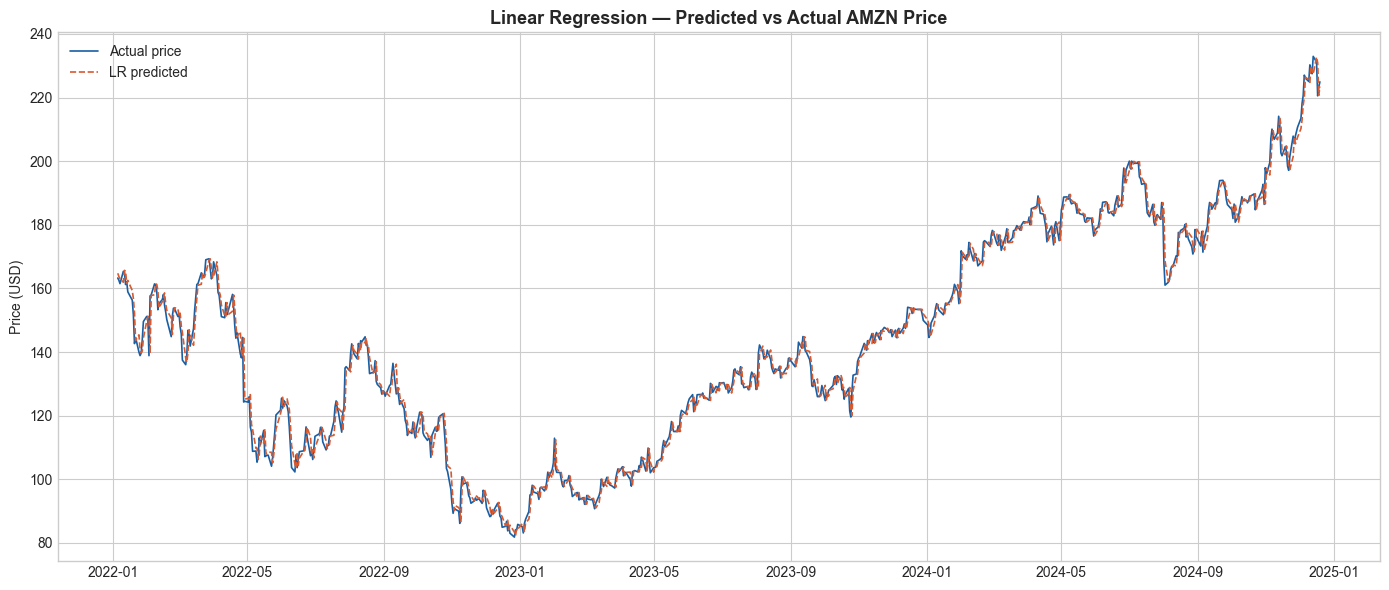

Saved to outputs/


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test['date'], y_test.values,
        color='#185FA5', linewidth=1.2, label='Actual price')
ax.plot(test['date'], lr_preds,
        color='#D85A30', linewidth=1.2, linestyle='--', label='LR predicted')

ax.set_title('Linear Regression — Predicted vs Actual AMZN Price',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/lr_predictions.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## Model 3 — Random Forest

A Random Forest builds hundreds of decision trees and averages their predictions. It handles non-linear relationships in the data that Linear Regression cannot capture, and is widely used in financial ML.

In [9]:
# Train (no scaling needed for tree-based models)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))

print(f"Random Forest RMSE: ${rf_rmse:.2f}")
print(f"Linear Reg RMSE:    ${lr_rmse:.2f}")
print(f"Baseline RMSE:      ${baseline_rmse:.2f}")

Random Forest RMSE: $12.53
Linear Reg RMSE:    $3.32
Baseline RMSE:      $3.30


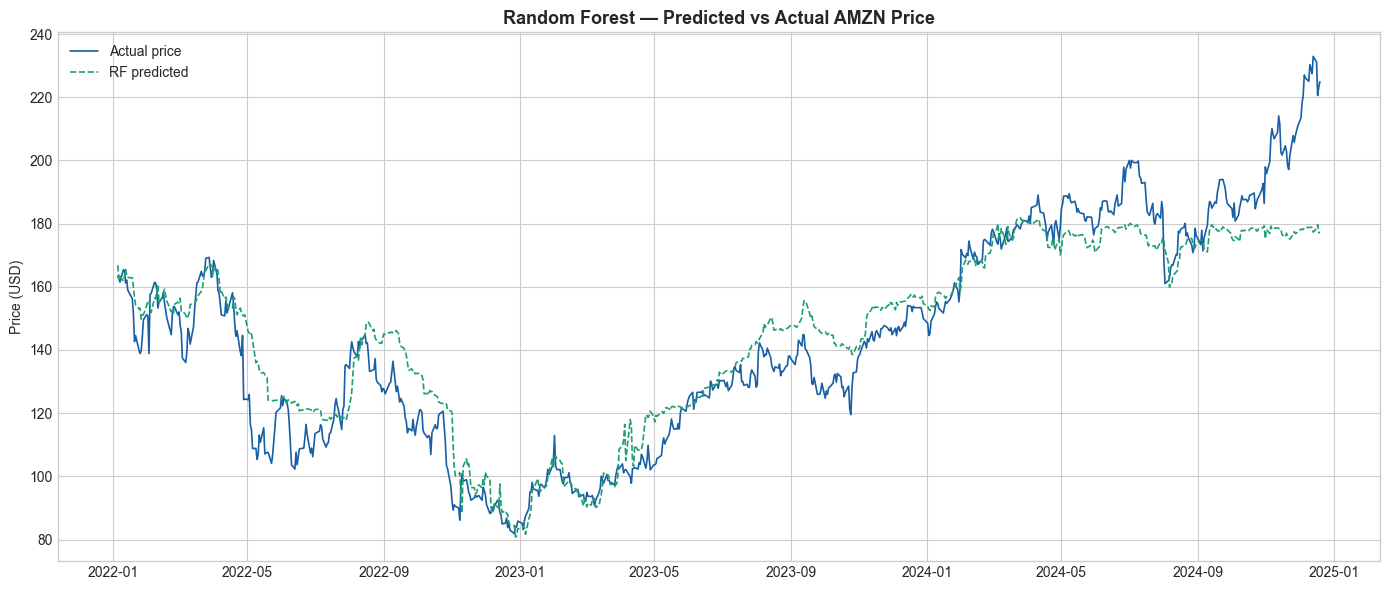

Saved to outputs/


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test['date'], y_test.values,
        color='#185FA5', linewidth=1.2, label='Actual price')
ax.plot(test['date'], rf_preds,
        color='#1D9E75', linewidth=1.2, linestyle='--', label='RF predicted')

ax.set_title('Random Forest — Predicted vs Actual AMZN Price',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/rf_predictions.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

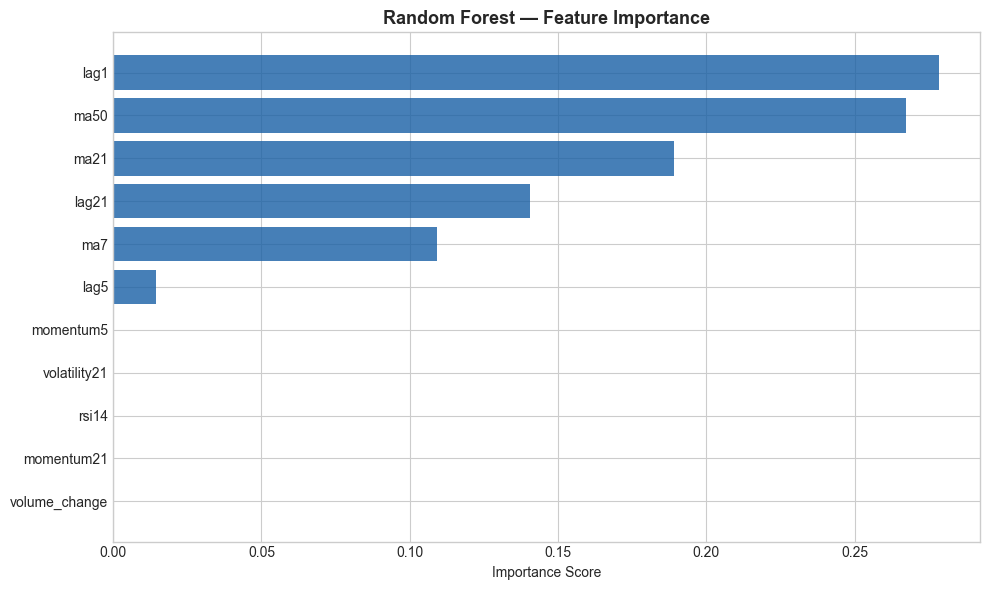


Top 3 most important features:
feature  importance
   ma21    0.189218
   ma50    0.267461
   lag1    0.278391


In [11]:
importance_df = pd.DataFrame({
    'feature':   feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color='#185FA5', alpha=0.8)
ax.set_title('Random Forest — Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/feature_importance.png',
            dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
print(importance_df.tail(3)[['feature','importance']].to_string(index=False))

In [12]:
results = pd.DataFrame({
    'Model':       ['Naive Baseline', 'Linear Regression', 'Random Forest'],
    'RMSE ($)':    [round(baseline_rmse, 2), round(lr_rmse, 2), round(rf_rmse, 2)],
    'Beat baseline': [
        'No — this IS the baseline',
        f'Yes — ${baseline_rmse - lr_rmse:.2f} improvement',
        f'Yes — ${baseline_rmse - rf_rmse:.2f} improvement'
    ]
})

print("=== Model Comparison ===")
print(results.to_string(index=False))

# Save results
results.to_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/model_comparison.csv',
               index=False)
print("\nSaved to outputs/model_comparison.csv")

=== Model Comparison ===
            Model  RMSE ($)             Beat baseline
   Naive Baseline      3.30 No — this IS the baseline
Linear Regression      3.32  Yes — $-0.02 improvement
    Random Forest     12.53  Yes — $-9.23 improvement

Saved to outputs/model_comparison.csv


## Conclusion

Surprisingly, neither model meaningfully outperformed the naive baseline.
Linear Regression achieved an RMSE of $3.32. 

That is virtually identical to the baseline of $3.30. 

Random Forest performed significantly worse at $12.53, indicating severe
overfitting to the training data.
This is a common and important finding in financial ML — stock prices
are highly efficient and difficult to predict from technical indicators
alone. The dominant feature (lag1 — yesterday's price) essentially
replicates the naive baseline strategy.

Potential improvements for future work:
- Tune Random Forest hyperparameters (max_depth, min_samples_leaf)
  to reduce overfitting
- Add fundamental data (P/E ratio, earnings) as features
- Predict price direction (up/down) instead of exact price level
- Use walk-forward validation instead of a single train/test split